In [1]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<jemalloc>: Unsupported system page size


In [2]:
# Variables
path = f"/datasets/multi-view-pig-posture-recognition"
train1_path = f"{path}/train1.csv"
train1_images_path = f"{path}/train1_images"
train2_path = f"{path}/train2.csv"
train2_images_path = f"{path}/train2_images"
test_path = f"{path}/test.csv"
test_images_path = f"{path}/test_images"
sample_submission_path = f"{path}/sample_submission.csv"
txt_path = f"{path}/pig_posture_classes.txt"

In [3]:
# convert formats
train1_df = pd.read_csv(train1_path)
train2_df = pd.read_csv(train2_path)
test_df = pd.read_csv(test_path)
sample_submission_df = pd.read_csv(sample_submission_path)
# print the first line of each csv
print("Train1 DataFrame:")
print(train1_df.head(1))
print("\nTrain2 DataFrame:")
print(train2_df.head(1))
print("\nTest DataFrame:")
print(test_df.head(1))
print("\nSample Submission DataFrame:")
print(sample_submission_df.head(1))

Train1 DataFrame:
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  

Train2 DataFrame:
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  

Test DataFrame:
                                    row_id                           image_id  \
0  test_pen1_tur_cam1_20250920_174649_0000  pen1_tur_cam1_20250920_174649.jpg   

   width  height                       bbox  
0   1280     720  [432.0,291.0,306.0,394.0]  

Sample Submission DataFrame:
                                    row_id  class_id
0  test_pen1_tur_cam1_202509

In [4]:
# convert class_id to string using the txt
with open(txt_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
class_id_to_name = {i: name for i, name in enumerate(class_names)}

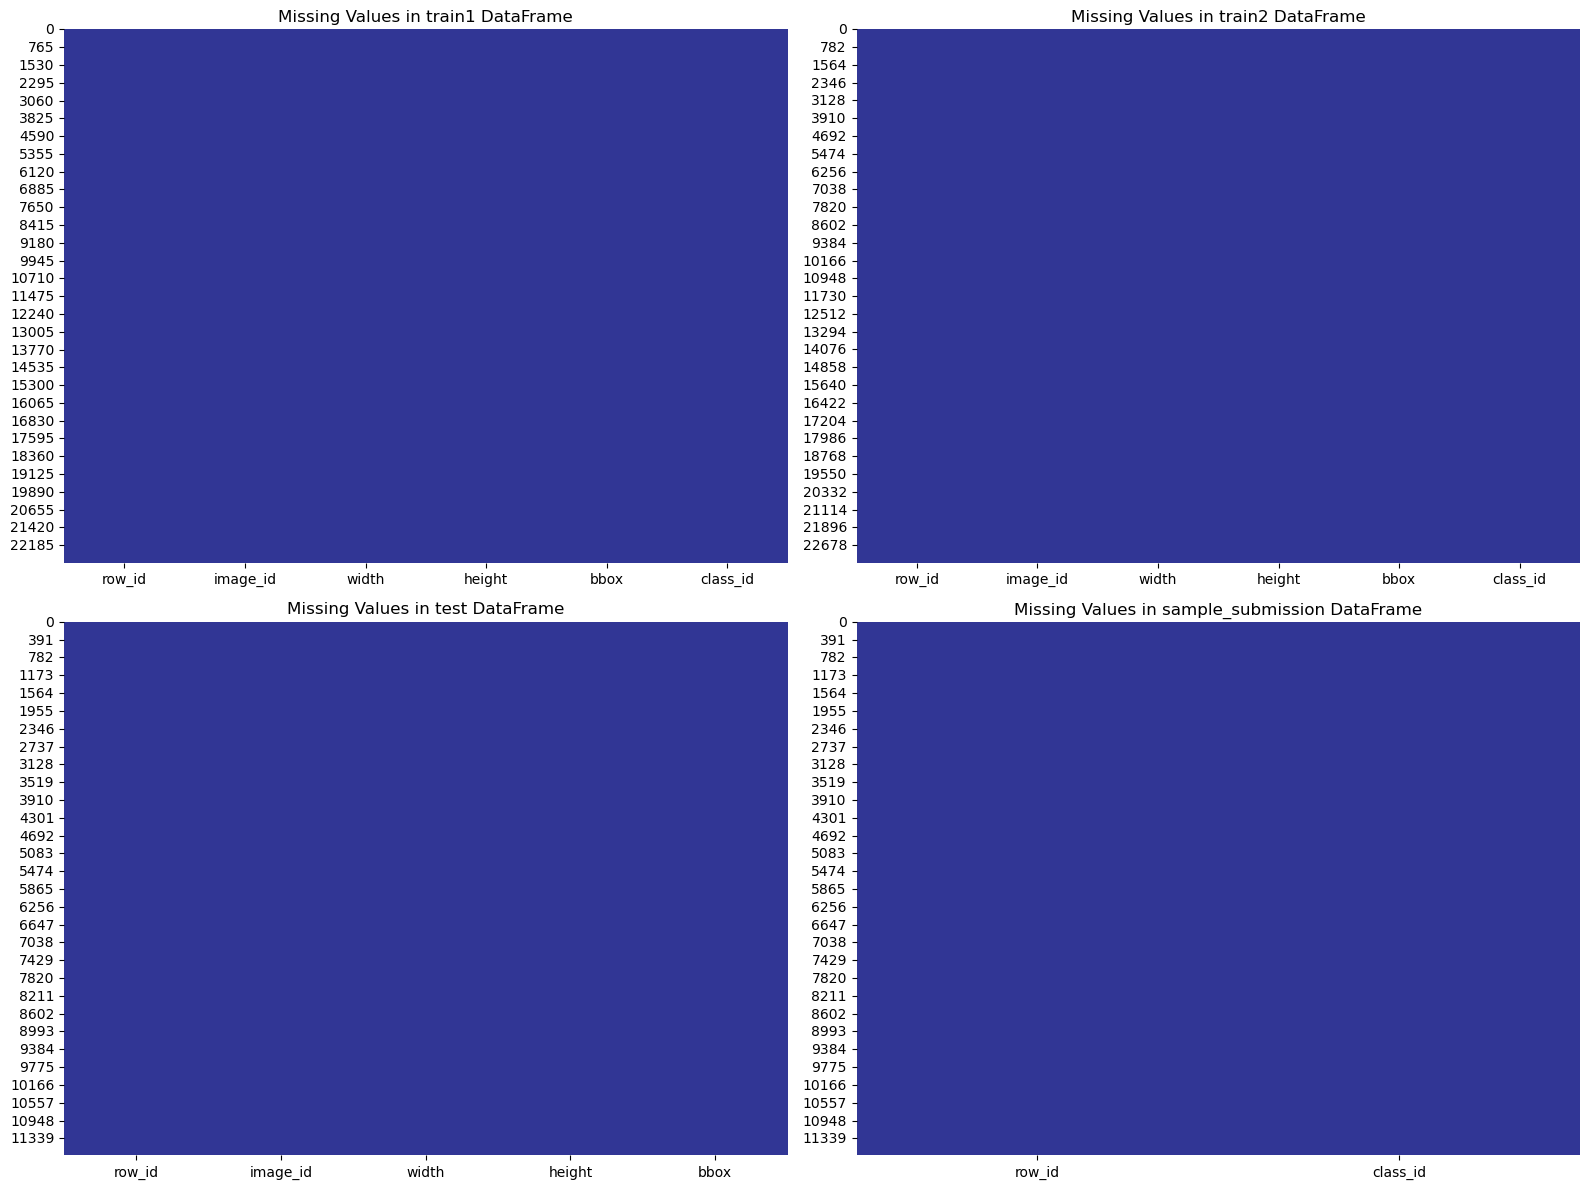

In [5]:
data = {
    "train1": train1_df,
    "train2": train2_df,
    "test": test_df,
    "sample_submission": sample_submission_df
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, df) in enumerate(data.items()):
    sns.heatmap(df.isnull(), cbar=False, cmap='RdYlBu_r', ax=axes[i])
    axes[i].set_title(f'Missing Values in {name} DataFrame')

plt.tight_layout()
plt.show()

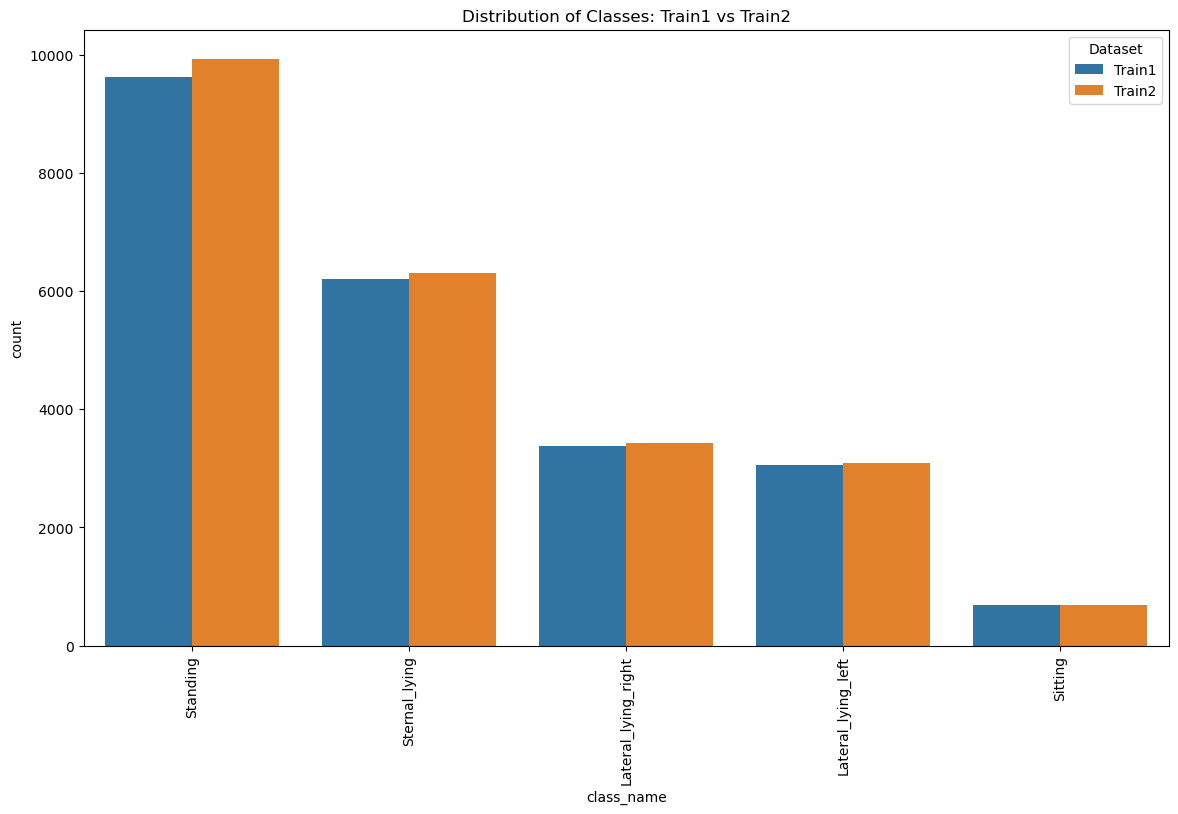

In [6]:
# Create combined DataFrame with source information and convert class_id to names
train1_labeled = train1_df.copy()
train1_labeled['source'] = 'Train1'
train1_labeled['class_name'] = train1_labeled['class_id'].map(class_id_to_name)

train2_labeled = train2_df.copy()
train2_labeled['source'] = 'Train2'
train2_labeled['class_name'] = train2_labeled['class_id'].map(class_id_to_name)

combined_labeled_df = pd.concat([train1_labeled, train2_labeled])

# Create single plot with different colors for each dataset
plt.figure(figsize=(14, 8))
sns.countplot(data=combined_labeled_df, x='class_name', hue='source', 
              order=combined_labeled_df['class_name'].value_counts().index)
plt.title('Distribution of Classes: Train1 vs Train2')
plt.xticks(rotation=90)
plt.legend(title='Dataset')
plt.show()

In [7]:
#drop row_id from test1 and test2 since it contains redundant information
train1_df.drop(columns=['row_id'], inplace=True)
train2_df.drop(columns=['row_id'], inplace=True)
train1_df.head()

,image_id,width,height,bbox,class_id
0,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


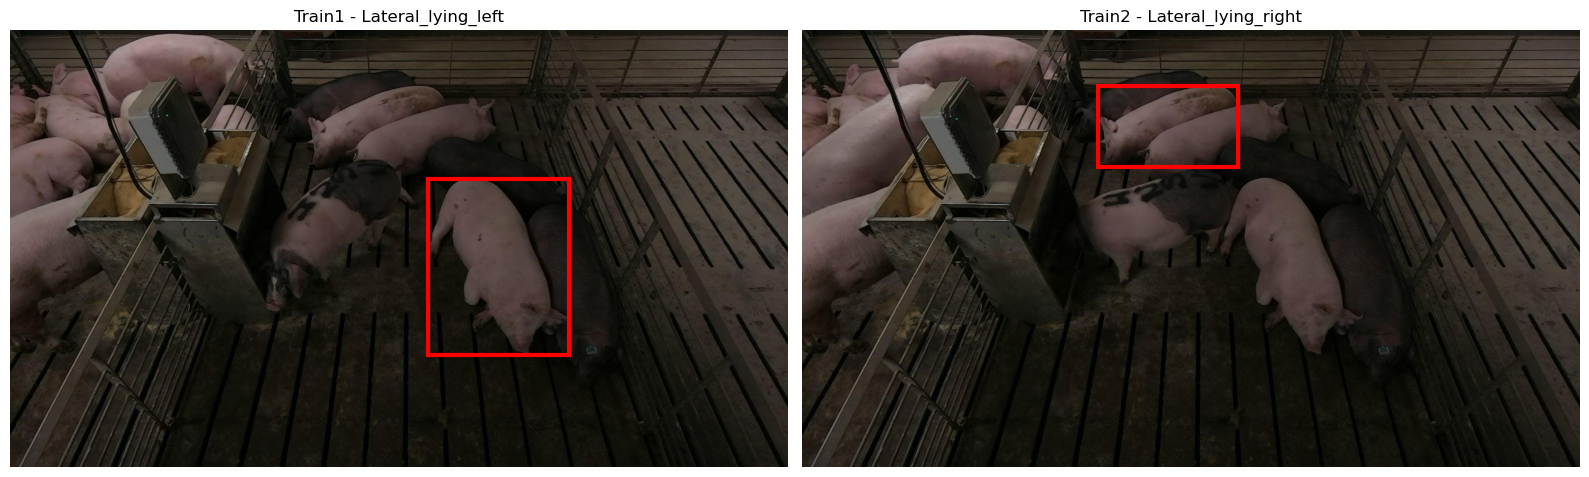

In [8]:
import cv2
from matplotlib.patches import Rectangle
import ast

# Get first row from each dataset. Wer are picking 2 different immages as a proof of concept
first_train1 = train1_df.iloc[0]
first_train2 = train2_df.iloc[30]

# Load images
img1_path = f"{train1_images_path}/{first_train1['image_id']}"
img2_path = f"{train2_images_path}/{first_train2['image_id']}"

img1 = cv2.imread(img1_path)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.imread(img2_path)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Parse bbox coordinates (assuming format: [x, y, width, height])
bbox1 = ast.literal_eval(first_train1['bbox']) if isinstance(first_train1['bbox'], str) else first_train1['bbox']
bbox2 = ast.literal_eval(first_train2['bbox']) if isinstance(first_train2['bbox'], str) else first_train2['bbox']

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot first image with bbox
axes[0].imshow(img1)
rect1 = Rectangle((bbox1[0], bbox1[1]), bbox1[2], bbox1[3], linewidth=3, edgecolor='red', facecolor='none')
axes[0].add_patch(rect1)
axes[0].set_title(f'Train1 - {class_id_to_name[first_train1["class_id"]]}')
axes[0].axis('off')

# Plot second image with bbox
axes[1].imshow(img2)
rect2 = Rectangle((bbox2[0], bbox2[1]), bbox2[2], bbox2[3], linewidth=3, edgecolor='red', facecolor='none')
axes[1].add_patch(rect2)
axes[1].set_title(f'Train2 - {class_id_to_name[first_train2["class_id"]]}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

CUDA available: Tesla V100-SXM2-32GB
CUDA memory: 31.5 GB


/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

Model device: cuda:0
Training on cuda
PyTorch version: 1.12.1
Number of classes: 5
Training samples: 18347
Validation samples: 4587
Batch size: 64
Mixed precision: Enabled

Epoch 1/10


Validation: 100%|██████████| 72/72 [00:26<00:00,  2.68it/s]


...

Train Loss: 0.1630, Train Acc: 94.33%
Val Loss: 0.2630, Val Acc: 91.67%
GPU Memory: 0.17GB / 1.09GB

Epoch 9/10


Validation: 100%|██████████| 72/72 [00:26<00:00,  2.71it/s]


Train Loss: 0.0984, Train Acc: 96.80%
Val Loss: 0.2193, Val Acc: 93.53%
GPU Memory: 0.17GB / 1.09GB

Epoch 10/10


Validation: 100%|██████████| 72/72 [00:26<00:00,  2.74it/s]


Train Loss: 0.0645, Train Acc: 98.04%
Val Loss: 0.2179, Val Acc: 93.44%
GPU Memory: 0.17GB / 1.09GB


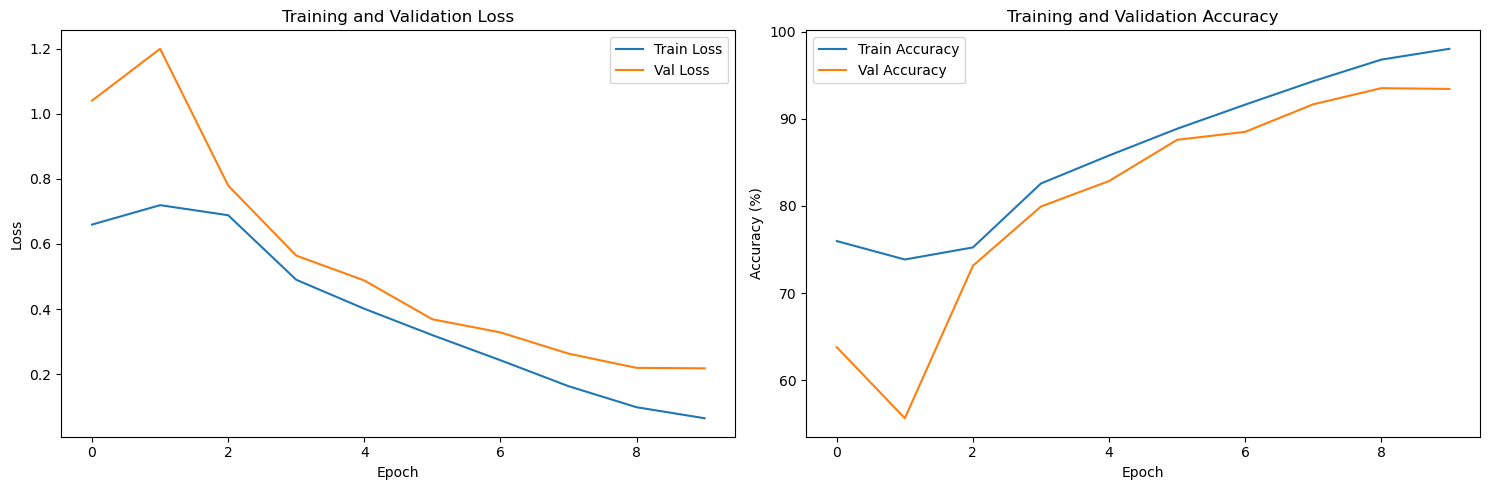


Model saved as 'resnet18_pig_posture_optimized.pth'


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import cv2
import ast
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Check GPU availability and memory
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    device = torch.device('cuda')
else:
    print("CUDA not available, using CPU")
    device = torch.device('cpu')

class PigPostureDataset(Dataset):
    def __init__(self, dataframe, images_path, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.images_path = images_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
            
            # Load image
            img_path = f"{self.images_path}/{row['image_id']}"
            image = cv2.imread(img_path)
            if image is None:
                raise ValueError(f"Could not load image: {img_path}")
            
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Parse bbox and crop
            bbox = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
            
            # Convert to integers and ensure valid bounds
            x, y, w, h = [int(coord) for coord in bbox]
            img_height, img_width = image.shape[:2]
            
            # Clamp coordinates to image bounds
            x = max(0, min(x, img_width - 1))
            y = max(0, min(y, img_height - 1))
            x2 = min(x + w, img_width)
            y2 = min(y + h, img_height)
            
            # Ensure we have a valid crop region
            if x2 <= x or y2 <= y:
                x, y, x2, y2 = 0, 0, img_width, img_height
            
            cropped_image = image[y:y2, x:x2]
            
            # Convert to PIL Image
            cropped_image = Image.fromarray(cropped_image)
            
            if self.transform:
                cropped_image = self.transform(cropped_image)
            
            return cropped_image, torch.tensor(row['class_id'], dtype=torch.long)
        
        except Exception as e:
            print(f"Error processing index {idx}: {e}")
            # Return a dummy sample
            dummy_img = torch.zeros(3, 224, 224)
            return dummy_img, torch.tensor(0, dtype=torch.long)

# Optimized data transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split train1 data
train_df, val_df = train_test_split(train1_df, test_size=0.2, random_state=42, stratify=train1_df['class_id'])

# Create datasets and dataloaders
train_dataset = PigPostureDataset(train_df, train1_images_path, transform_train)
val_dataset = PigPostureDataset(val_df, train1_images_path, transform_val)

# DataLoaders (without persistent_workers for compatibility)
train_loader = DataLoader(
    train_dataset, 
    batch_size=64,
    shuffle=True, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Initialize ResNet18 model
num_classes = len(class_names)
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move to GPU
model = model.to(device)

# Verify model is on GPU
if torch.cuda.is_available():
    print(f"Model device: {next(model.parameters()).device}")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(train_loader), epochs=10)

# Check if mixed precision is available
try:
    from torch.cuda.amp import GradScaler, autocast
    scaler = GradScaler() if torch.cuda.is_available() else None
    use_amp = True
except ImportError:
    print("Mixed precision not available, using regular training")
    scaler = None
    use_amp = False

# Training function
def train_epoch(model, train_loader, criterion, optimizer, scheduler, device, scaler=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc="Training")
    for batch_idx, (inputs, labels) in enumerate(pbar):
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        if scaler is not None and use_amp:  # Mixed precision
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:  # Regular training
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        scheduler.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar every 50 batches
        if batch_idx % 50 == 0:
            current_acc = 100. * correct / total
            pbar.set_postfix({'Loss': f'{running_loss/(batch_idx+1):.4f}', 'Acc': f'{current_acc:.2f}%'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, val_loader, criterion, device, scaler=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            if scaler is not None and use_amp:
                with autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# Training setup
num_epochs = 10
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print(f"Training on {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {train_loader.batch_size}")
print(f"Mixed precision: {'Enabled' if use_amp else 'Disabled'}")

# Clear GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Training loop
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, device, scaler)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device, scaler)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # GPU memory info
    if torch.cuda.is_available():
        print(f"GPU Memory: {torch.cuda.memory_allocated()/1024**3:.2f}GB / {torch.cuda.memory_reserved()/1024**3:.2f}GB")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(val_accs, label='Val Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

# Save the trained model
torch.save(model.state_dict(), 'resnet18_pig_posture_optimized.pth')
print("\nModel saved as 'resnet18_pig_posture_optimized.pth'")

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import cv2
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class PigPostureTestDataset(Dataset):
    def __init__(self, dataframe, images_path, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.images_path = images_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
            
            # Load image
            img_path = f"{self.images_path}/{row['image_id']}"
            image = cv2.imread(img_path)
            if image is None:
                raise ValueError(f"Could not load image: {img_path}")
            
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Parse bbox and crop
            bbox = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
            
            # Convert to integers and ensure valid bounds
            x, y, w, h = [int(coord) for coord in bbox]
            img_height, img_width = image.shape[:2]
            
            # Clamp coordinates to image bounds
            x = max(0, min(x, img_width - 1))
            y = max(0, min(y, img_height - 1))
            x2 = min(x + w, img_width)
            y2 = min(y + h, img_height)
            
            # Ensure we have a valid crop region
            if x2 <= x or y2 <= y:
                x, y, x2, y2 = 0, 0, img_width, img_height
            
            cropped_image = image[y:y2, x:x2]
            
            # Convert to PIL Image
            cropped_image = Image.fromarray(cropped_image)
            
            if self.transform:
                cropped_image = self.transform(cropped_image)
            
            # Return row_id as string (don't convert to int)
            return cropped_image, str(row['row_id'])
        
        except Exception as e:
            print(f"Error processing index {idx}: {e}")
            # Return a dummy sample
            dummy_img = torch.zeros(3, 224, 224)
            return dummy_img, str(row['row_id']) if 'row_id' in row else f"dummy_{idx}"

# Test transform (same as validation)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create test dataset and dataloader
test_dataset = PigPostureTestDataset(test_df, test_images_path, transform_test)
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Load the trained model
print("Loading trained model...")
num_classes = len(class_names)
model = models.resnet18(pretrained=False)  # Don't load pretrained weights
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Load the saved state dict
try:
    model.load_state_dict(torch.load('resnet18_pig_posture_optimized.pth', map_location=device))
    print("Model loaded successfully!")
except FileNotFoundError:
    print("Model file not found! Please train the model first.")
    raise

# Move model to device
model = model.to(device)
model.eval()

# Run inference
print("Running inference on test data...")
predictions = []
row_ids = []

# Check if mixed precision is available for inference
try:
    from torch.cuda.amp import autocast
    use_amp = True
except ImportError:
    use_amp = False

with torch.no_grad():
    for inputs, batch_row_ids in tqdm(test_loader, desc="Predicting"):
        inputs = inputs.to(device, non_blocking=True)
        
        if use_amp and torch.cuda.is_available():
            with autocast():
                outputs = model(inputs)
        else:
            outputs = model(inputs)
        
        # Get predicted class
        _, predicted = torch.max(outputs, 1)
        
        # Store predictions and row_ids
        predictions.extend(predicted.cpu().numpy().tolist())
        
        # Handle row_ids - they are already strings, just extend the list
        row_ids.extend(batch_row_ids)

# Create submission dataframe
submission_df = pd.DataFrame({
    'row_id': row_ids,
    'class_id': predictions
})

# Sort by row_id to ensure proper order (lexicographically for strings)
submission_df = submission_df.sort_values('row_id').reset_index(drop=True)

# Display some statistics
print(f"\nSubmission Statistics:")
print(f"Total predictions: {len(submission_df)}")
print(f"Unique row_ids: {submission_df['row_id'].nunique()}")

# Display class distribution with proper error handling
print(f"Class distribution:")
class_counts = submission_df['class_id'].value_counts().sort_index()
for class_id, count in class_counts.items():
    try:
        class_name = class_id_to_name[class_id]
        print(f"  {class_name} (ID {class_id}): {count} samples ({100*count/len(submission_df):.1f}%)")
    except (KeyError, NameError):
        print(f"  Class {class_id}: {count} samples ({100*count/len(submission_df):.1f}%)")

# Show first few predictions
print(f"\nFirst 10 predictions:")
print(submission_df.head(10))

# Verify format matches expected submission format
print(f"\nSubmission format verification:")
print(f"Columns: {list(submission_df.columns)}")
print(f"Column types: {submission_df.dtypes.tolist()}")

# Check against sample submission
print(f"Sample submission columns: {list(sample_submission_df.columns)}")
print(f"Expected rows: {len(sample_submission_df)}, Actual rows: {len(submission_df)}")

# Verify row_ids match sample submission
sample_row_ids = set(sample_submission_df['row_id'].astype(str))
submission_row_ids = set(submission_df['row_id'].astype(str))
print(f"Row IDs match sample submission: {sample_row_ids == submission_row_ids}")

if sample_row_ids != submission_row_ids:
    missing_in_submission = sample_row_ids - submission_row_ids
    extra_in_submission = submission_row_ids - sample_row_ids
    if missing_in_submission:
        print(f"Missing row_ids: {len(missing_in_submission)} (first 5: {list(missing_in_submission)[:5]})")
    if extra_in_submission:
        print(f"Extra row_ids: {len(extra_in_submission)} (first 5: {list(extra_in_submission)[:5]})")

# Save submission file
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"\nSubmission saved as '{submission_filename}'")

# Verify the saved file
print(f"File verification:")
saved_df = pd.read_csv(submission_filename)
print(f"Saved file shape: {saved_df.shape}")
print(f"Saved file head:")
print(saved_df.head())

print(f"\nSubmission ready! File: {submission_filename}")

Using device: cuda
Loading trained model...


/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully!
Running inference on test data...


Predicting: 100%|██████████| 183/183 [00:42<00:00,  4.33it/s]


Submission Statistics:
Total predictions: 11708
Unique row_ids: 11708
Class distribution:
  Lateral_lying_left (ID 0): 611 samples (5.2%)
  Lateral_lying_right (ID 1): 768 samples (6.6%)
  Sitting (ID 2): 880 samples (7.5%)
  Standing (ID 3): 6935 samples (59.2%)
  Sternal_lying (ID 4): 2514 samples (21.5%)

First 10 predictions:
                                    row_id  class_id
0  test_pen1_tur_cam1_20250920_174649_0000         3
1  test_pen1_tur_cam1_20250920_174649_0001         0
2  test_pen1_tur_cam1_20250920_174649_0002         0
3  test_pen1_tur_cam1_20250920_174649_0003         3
4  test_pen1_tur_cam1_20250920_174649_0004         1
5  test_pen1_tur_cam1_20250920_174649_0005         1
6  test_pen1_tur_cam1_20250920_174649_0006         1
7  test_pen1_tur_cam1_20250920_174649_0007         0
8  test_pen1_tur_cam1_20250920_174649_0008         3
9  test_pen1_tur_cam1_20250921_050022_0000         1

Submission format verification:
Columns: ['row_id', 'class_id']
Column types: [dtyp

/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Continuing training with train2 dataset...
Loading previously trained model...
Model loaded successfully!
Fine-tuning setup:
Train2 training samples: 21105
Train2 validation samples: 2345
Learning rate: 3.9999999999999996e-05

Fine-tuning Epoch 1/5


Validation: 100%|██████████| 72/72 [00:25<00:00,  2.80it/s]


Train2 Loss: 0.1202, Train2 Acc: 96.32%
Train2 Val Loss: 0.1120, Train2 Val Acc: 96.08%
Original Val Loss: 0.1717, Original Val Acc: 94.57%
GPU Memory: 0.37GB / 1.29GB

Fine-tuning Epoch 2/5


Validation: 100%|██████████| 72/72 [00:25<00:00,  2.80it/s]


...

Train2 Loss: 0.1018, Train2 Acc: 96.51%
Train2 Val Loss: 0.1294, Train2 Val Acc: 95.78%
Original Val Loss: 0.0892, Original Val Acc: 97.34%
GPU Memory: 0.37GB / 1.29GB

Fine-tuning Epoch 4/5


Validation: 100%|██████████| 72/72 [00:34<00:00,  2.07it/s]


Train2 Loss: 0.0616, Train2 Acc: 97.96%
Train2 Val Loss: 0.1118, Train2 Val Acc: 96.42%
Original Val Loss: 0.0617, Original Val Acc: 98.30%
GPU Memory: 0.37GB / 1.29GB

Fine-tuning Epoch 5/5


Validation: 100%|██████████| 72/72 [00:28<00:00,  2.52it/s]


Train2 Loss: 0.0395, Train2 Acc: 98.81%
Train2 Val Loss: 0.1094, Train2 Val Acc: 96.67%
Original Val Loss: 0.0566, Original Val Acc: 98.34%
GPU Memory: 0.37GB / 1.29GB


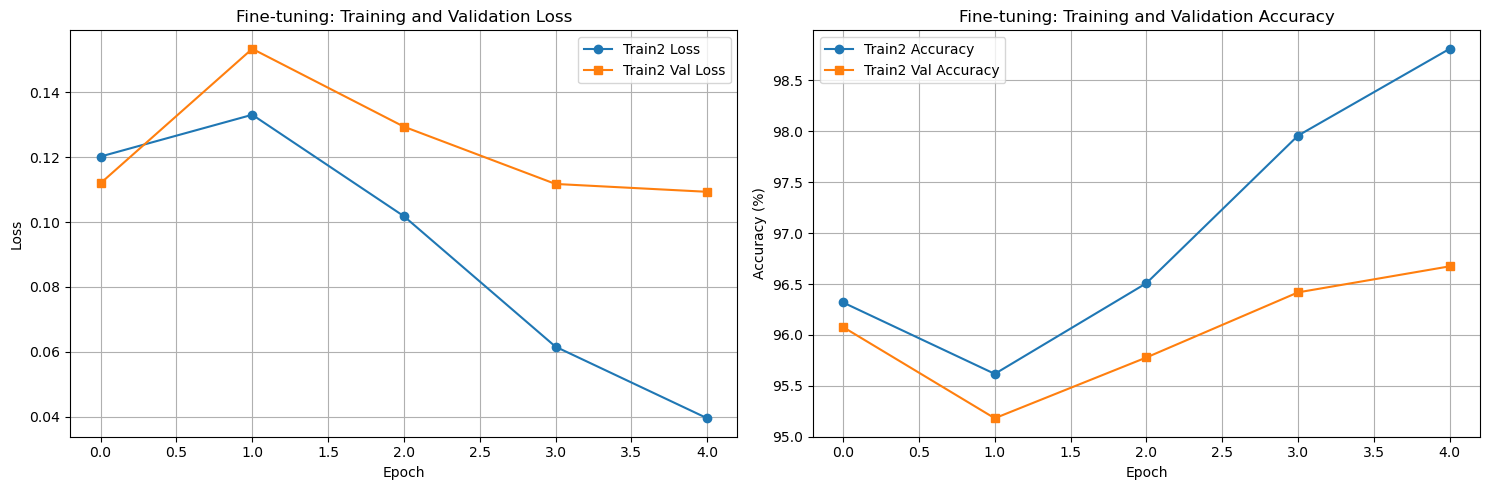


Fine-tuned model saved as 'resnet18_pig_posture_finetuned.pth'

Final evaluation on original validation set:


Validation: 100%|██████████| 72/72 [00:26<00:00,  2.77it/s]

Final Validation Loss: 0.0566
Final Validation Accuracy: 98.34%

Comparison:
Train1-only model best val accuracy: 93.53%
Fine-tuned model val accuracy: 98.34%
Improvement: 4.82%

Train2 dataset class distribution:
  Lateral_lying_left (ID 0): 3083 samples (13.1%)
  Lateral_lying_right (ID 1): 3435 samples (14.6%)
  Sitting (ID 2): 695 samples (3.0%)
  Standing (ID 3): 9928 samples (42.3%)
  Sternal_lying (ID 4): 6309 samples (26.9%)

Fine-tuning complete! Use 'resnet18_pig_posture_finetuned.pth' for final predictions.


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

print("Continuing training with train2 dataset...")

# Load the existing trained model
print("Loading previously trained model...")
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Load the saved state dict
model.load_state_dict(torch.load('resnet18_pig_posture_optimized.pth', map_location=device))
model = model.to(device)
print("Model loaded successfully!")

# Create train2 dataset with same transforms
train2_dataset = PigPostureDataset(train2_df, train2_images_path, transform_train)

# Split train2 for validation (small portion for monitoring)
train2_train, train2_val = train_test_split(train2_df, test_size=0.1, random_state=42, stratify=train2_df['class_id'])

train2_train_dataset = PigPostureDataset(train2_train, train2_images_path, transform_train)
train2_val_dataset = PigPostureDataset(train2_val, train2_images_path, transform_val)

# Create dataloaders for train2
train2_loader = DataLoader(
    train2_train_dataset, 
    batch_size=64,
    shuffle=True, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

train2_val_loader = DataLoader(
    train2_val_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Use lower learning rate for fine-tuning
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)  # Lower LR
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.001, steps_per_epoch=len(train2_loader), epochs=5)

# Check if mixed precision is available
try:
    from torch.cuda.amp import GradScaler, autocast
    scaler = GradScaler() if torch.cuda.is_available() else None
    use_amp = True
except ImportError:
    scaler = None
    use_amp = False

print(f"Fine-tuning setup:")
print(f"Train2 training samples: {len(train2_train_dataset)}")
print(f"Train2 validation samples: {len(train2_val_dataset)}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

# Store metrics for both phases
train2_losses, train2_accs = [], []
train2_val_losses, train2_val_accs = [], []

# Fine-tuning epochs
fine_tune_epochs = 5

# Clear GPU cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Fine-tuning loop
for epoch in range(fine_tune_epochs):
    print(f"\nFine-tuning Epoch {epoch+1}/{fine_tune_epochs}")
    
    # Train on train2
    train_loss, train_acc = train_epoch(model, train2_loader, criterion, optimizer, scheduler, device, scaler)
    
    # Validate on train2 validation set
    val_loss, val_acc = validate_epoch(model, train2_val_loader, criterion, device, scaler)
    
    # Also validate on original validation set to monitor performance
    orig_val_loss, orig_val_acc = validate_epoch(model, val_loader, criterion, device, scaler)
    
    # Store metrics
    train2_losses.append(train_loss)
    train2_accs.append(train_acc)
    train2_val_losses.append(val_loss)
    train2_val_accs.append(val_acc)
    
    print(f"Train2 Loss: {train_loss:.4f}, Train2 Acc: {train_acc:.2f}%")
    print(f"Train2 Val Loss: {val_loss:.4f}, Train2 Val Acc: {val_acc:.2f}%")
    print(f"Original Val Loss: {orig_val_loss:.4f}, Original Val Acc: {orig_val_acc:.2f}%")
    
    # GPU memory info
    if torch.cuda.is_available():
        print(f"GPU Memory: {torch.cuda.memory_allocated()/1024**3:.2f}GB / {torch.cuda.memory_reserved()/1024**3:.2f}GB")

# Plot fine-tuning progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train2_losses, label='Train2 Loss', marker='o')
ax1.plot(train2_val_losses, label='Train2 Val Loss', marker='s')
ax1.set_title('Fine-tuning: Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train2_accs, label='Train2 Accuracy', marker='o')
ax2.plot(train2_val_accs, label='Train2 Val Accuracy', marker='s')
ax2.set_title('Fine-tuning: Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Save the fine-tuned model
torch.save(model.state_dict(), 'resnet18_pig_posture_finetuned.pth')
print("\nFine-tuned model saved as 'resnet18_pig_posture_finetuned.pth'")

# Evaluate final performance on original validation set
print("\nFinal evaluation on original validation set:")
final_val_loss, final_val_acc = validate_epoch(model, val_loader, criterion, device, scaler)
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")

# Compare with train1-only model performance
print("\nComparison:")
print(f"Train1-only model best val accuracy: {max(val_accs):.2f}%")
print(f"Fine-tuned model val accuracy: {final_val_acc:.2f}%")
improvement = final_val_acc - max(val_accs)
print(f"Improvement: {improvement:.2f}%")

# Display class distribution for train2
print("\nTrain2 dataset class distribution:")
train2_class_counts = train2_df['class_id'].value_counts().sort_index()
for class_id, count in train2_class_counts.items():
    class_name = class_id_to_name[class_id]
    percentage = 100 * count / len(train2_df)
    print(f"  {class_name} (ID {class_id}): {count} samples ({percentage:.1f}%)")

print(f"\nFine-tuning complete! Use 'resnet18_pig_posture_finetuned.pth' for final predictions.")

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import cv2
import ast
import numpy as np
import pandas as pd
from tqdm import tqdm

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class PigPostureTestDataset(Dataset):
    def __init__(self, dataframe, images_path, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.images_path = images_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
            
            # Load image
            img_path = f"{self.images_path}/{row['image_id']}"
            image = cv2.imread(img_path)
            if image is None:
                raise ValueError(f"Could not load image: {img_path}")
            
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Parse bbox and crop
            bbox = ast.literal_eval(row['bbox']) if isinstance(row['bbox'], str) else row['bbox']
            
            # Convert to integers and ensure valid bounds
            x, y, w, h = [int(coord) for coord in bbox]
            img_height, img_width = image.shape[:2]
            
            # Clamp coordinates to image bounds
            x = max(0, min(x, img_width - 1))
            y = max(0, min(y, img_height - 1))
            x2 = min(x + w, img_width)
            y2 = min(y + h, img_height)
            
            # Ensure we have a valid crop region
            if x2 <= x or y2 <= y:
                x, y, x2, y2 = 0, 0, img_width, img_height
            
            cropped_image = image[y:y2, x:x2]
            
            # Convert to PIL Image
            cropped_image = Image.fromarray(cropped_image)
            
            if self.transform:
                cropped_image = self.transform(cropped_image)
            
            # Return row_id as string (don't convert to int)
            return cropped_image, str(row['row_id'])
        
        except Exception as e:
            print(f"Error processing index {idx}: {e}")
            # Return a dummy sample
            dummy_img = torch.zeros(3, 224, 224)
            return dummy_img, str(row['row_id']) if 'row_id' in row else f"dummy_{idx}"

# Test transform (same as validation)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create test dataset and dataloader
test_dataset = PigPostureTestDataset(test_df, test_images_path, transform_test)
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Load the trained model
print("Loading trained model...")
num_classes = len(class_names)
model = models.resnet18(pretrained=False)  # Don't load pretrained weights
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Load the saved state dict
try:
    model.load_state_dict(torch.load('resnet18_pig_posture_finetuned.pth', map_location=device))
    print("Model loaded successfully!")
except FileNotFoundError:
    print("Model file not found! Please train the model first.")
    raise

# Move model to device
model = model.to(device)
model.eval()

# Run inference
print("Running inference on test data...")
predictions = []
row_ids = []

# Check if mixed precision is available for inference
try:
    from torch.cuda.amp import autocast
    use_amp = True
except ImportError:
    use_amp = False

with torch.no_grad():
    for inputs, batch_row_ids in tqdm(test_loader, desc="Predicting"):
        inputs = inputs.to(device, non_blocking=True)
        
        if use_amp and torch.cuda.is_available():
            with autocast():
                outputs = model(inputs)
        else:
            outputs = model(inputs)
        
        # Get predicted class
        _, predicted = torch.max(outputs, 1)
        
        # Store predictions and row_ids
        predictions.extend(predicted.cpu().numpy().tolist())
        
        # Handle row_ids - they are already strings, just extend the list
        row_ids.extend(batch_row_ids)

# Create submission dataframe
submission_df = pd.DataFrame({
    'row_id': row_ids,
    'class_id': predictions
})

# Sort by row_id to ensure proper order (lexicographically for strings)
submission_df = submission_df.sort_values('row_id').reset_index(drop=True)

# Display some statistics
print(f"\nSubmission Statistics:")
print(f"Total predictions: {len(submission_df)}")
print(f"Unique row_ids: {submission_df['row_id'].nunique()}")

# Display class distribution with proper error handling
print(f"Class distribution:")
class_counts = submission_df['class_id'].value_counts().sort_index()
for class_id, count in class_counts.items():
    try:
        class_name = class_id_to_name[class_id]
        print(f"  {class_name} (ID {class_id}): {count} samples ({100*count/len(submission_df):.1f}%)")
    except (KeyError, NameError):
        print(f"  Class {class_id}: {count} samples ({100*count/len(submission_df):.1f}%)")

# Show first few predictions
print(f"\nFirst 10 predictions:")
print(submission_df.head(10))

# Verify format matches expected submission format
print(f"\nSubmission format verification:")
print(f"Columns: {list(submission_df.columns)}")
print(f"Column types: {submission_df.dtypes.tolist()}")

# Check against sample submission
print(f"Sample submission columns: {list(sample_submission_df.columns)}")
print(f"Expected rows: {len(sample_submission_df)}, Actual rows: {len(submission_df)}")

# Verify row_ids match sample submission
sample_row_ids = set(sample_submission_df['row_id'].astype(str))
submission_row_ids = set(submission_df['row_id'].astype(str))
print(f"Row IDs match sample submission: {sample_row_ids == submission_row_ids}")

if sample_row_ids != submission_row_ids:
    missing_in_submission = sample_row_ids - submission_row_ids
    extra_in_submission = submission_row_ids - sample_row_ids
    if missing_in_submission:
        print(f"Missing row_ids: {len(missing_in_submission)} (first 5: {list(missing_in_submission)[:5]})")
    if extra_in_submission:
        print(f"Extra row_ids: {len(extra_in_submission)} (first 5: {list(extra_in_submission)[:5]})")

# Save submission file
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"\nSubmission saved as '{submission_filename}'")

# Verify the saved file
print(f"File verification:")
saved_df = pd.read_csv(submission_filename)
print(f"Saved file shape: {saved_df.shape}")
print(f"Saved file head:")
print(saved_df.head())

print(f"\nSubmission ready! File: {submission_filename}")

/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/torch/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Using device: cuda
Loading trained model...
Model loaded successfully!
Running inference on test data...


Predicting: 100%|██████████| 183/183 [00:41<00:00,  4.38it/s]


Submission Statistics:
Total predictions: 11708
Unique row_ids: 11708
Class distribution:
  Lateral_lying_left (ID 0): 482 samples (4.1%)
  Lateral_lying_right (ID 1): 772 samples (6.6%)
  Sitting (ID 2): 435 samples (3.7%)
  Standing (ID 3): 7576 samples (64.7%)
  Sternal_lying (ID 4): 2443 samples (20.9%)

First 10 predictions:
                                    row_id  class_id
0  test_pen1_tur_cam1_20250920_174649_0000         3
1  test_pen1_tur_cam1_20250920_174649_0001         1
2  test_pen1_tur_cam1_20250920_174649_0002         0
3  test_pen1_tur_cam1_20250920_174649_0003         3
4  test_pen1_tur_cam1_20250920_174649_0004         1
5  test_pen1_tur_cam1_20250920_174649_0005         1
6  test_pen1_tur_cam1_20250920_174649_0006         1
7  test_pen1_tur_cam1_20250920_174649_0007         3
8  test_pen1_tur_cam1_20250920_174649_0008         3
9  test_pen1_tur_cam1_20250921_050022_0000         1

Submission format verification:
Columns: ['row_id', 'class_id']
Column types: [dtyp